In [1]:
import cv2
import time
import torch

from ultralytics import YOLO

import supervision as sv

from IPython.display import display, clear_output
from PIL import Image

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
if torch.cuda.is_available():
    device = 0
    print("GPU:")
    print(torch.cuda.get_device_name(0))

else:
    device = "cpu"
    print("Using CPU")

GPU:
NVIDIA GeForce GTX 1650


In [3]:
model = YOLO("yolo11n.pt")

print("YOLO11 loaded")

YOLO11 loaded


In [4]:
tracker = sv.ByteTrack()

print("ByteTrack initialized")

ByteTrack initialized


C:\Users\Acer\AppData\Local\Temp\ipykernel_31716\3879445296.py:1: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack()


In [5]:
cap = cv2.VideoCapture(0)


if not cap.isOpened():
    raise RuntimeError("Cannot access webcam")


print("Camera started")

Camera started


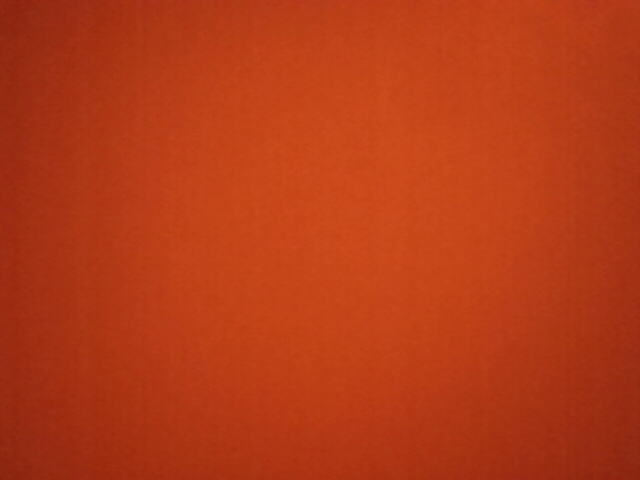

In [ ]:
while True:

    success, frame = cap.read()

    if not success:
        break


    # YOLO detection
    results = model.predict(
        frame,
        conf=0.35,
        device=device,
        verbose=False
    )[0]


    # Convert YOLO output to supervision format
    detections = sv.Detections.from_ultralytics(results)


    # Tracking
    detections = tracker.update_with_detections(
        detections
    )


    labels = []


    for class_id, tracker_id in zip(
        detections.class_id,
        detections.tracker_id
    ):

        labels.append(
            f"{model.names[class_id]} ID:{tracker_id}"
        )


    # Draw boxes and labels
    box_annotator = sv.BoxAnnotator()

    annotated = box_annotator.annotate(
        scene=frame.copy(),
        detections=detections
    )


    label_annotator = sv.LabelAnnotator()

    annotated = label_annotator.annotate(
        scene=annotated,
        detections=detections,
        labels=labels
    )


    # Display in notebook
    rgb = cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )


    clear_output(wait=True)

    display(
        Image.fromarray(rgb)
    )